# Post 07: How Do Trajectories Become Physical Observables?

This notebook is the presentation layer for the seventh tutorial. The reusable RDF, coordination, time-correlation, and compact argon trajectory logic lives in `src/kups_md_tutorials/`.

The goal is to treat observables as estimators with normalization, finite-size limits, trajectory correlation, and uncertainty, not as raw trajectory pictures.


In [1]:
from pathlib import Path
import json
import os

from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "configs").exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
repo_root

PosixPath('/home/sungs/kups-md-tutorials')

In [2]:
from kups_md_tutorials.figures import generate_post07_figures
from kups_md_tutorials.observables import load_observable_summary

## Configuration

The smoke and full profiles use periodic argon FCC cells with seeded thermal displacements. The comparison is deliberately finite-size focused: the RDF and coordination estimates are computed from the same estimator for small and large cells. Both profiles also include a compact reduced-unit argon Langevin trajectory so the same observable estimators can be checked on actual time-correlated frames.


In [3]:
for profile in ["smoke", "full"]:
    print(f"--- {profile} ---")
    print(json.dumps(json.loads(Path(f"configs/post-07/{profile}.json").read_text()), indent=2))

--- smoke ---
{
  "post": "07",
  "profile": "smoke",
  "title": "How Do Trajectories Become Physical Observables?",
  "observable_experiment": {
    "number_density": 0.021,
    "displacement_sigma": 0.1,
    "frame_count": 80,
    "sample_every": 1,
    "seed": 2026071407,
    "rdf_max_radius": 8.0,
    "rdf_bin_width": 0.08,
    "coordination_cutoff": 4.6,
    "velocity_correlation_time": 8.0,
    "max_vacf_lag": 40,
    "systems": [
      {
        "name": "small_cell",
        "repetitions": 2
      },
      {
        "name": "large_cell",
        "repetitions": 3
      }
    ]
  },
  "argon_trajectory": {
    "repetitions": 2,
    "number_density": 0.85,
    "temperature": 0.7,
    "gamma": 1.0,
    "time_step": 0.002,
    "num_steps": 3000,
    "warmup_steps": 500,
    "sample_every": 20,
    "seed": 2026071707,
    "rdf_max_radius": 3.0,
    "rdf_bin_width": 0.04,
    "coordination_cutoff": 1.45,
    "max_vacf_lag": 50,
    "epsilon": 1.0,
    "sigma": 1.0,
    "cutoff": 2.5
  

## Committed Results

The summary stores RDF peak locations, coordination integrals, block standard errors, and velocity-autocorrelation diagnostics. The `argon_trajectory` block records the same RDF, coordination, and VACF diagnostics for sampled frames from a compact reduced-unit trajectory.


In [4]:
summary = load_observable_summary(Path("results/post-07/full/observable_summary.json"))
for system in summary.systems:
    print(
        system.system,
        "N=", system.atom_count,
        "peak r=", round(system.rdf_first_peak_radius, 3),
        "coordination=", round(system.coordination_number, 3),
        "+/-", round(system.coordination_block_standard_error, 3),
    )
print("VACF integral=", round(summary.vacf.normalized_integral, 3))

argon = summary.argon_trajectory
if argon is not None:
    print("--- argon trajectory ---")
    print(
        "N=", argon.atom_count,
        "frames=", argon.frame_count,
        "peak r=", round(argon.rdf_first_peak_radius, 3),
        "coordination=", round(argon.coordination_number, 3),
        "VACF lag1=", round(argon.vacf_lag1_autocorrelation, 3),
    )


small_cell N= 32 peak r= 4.075 coordination= 11.999 +/- 0.0
large_cell N= 256 peak r= 4.075 coordination= 11.999 +/- 0.0
VACF integral= 12.036
--- argon trajectory ---
N= 108 frames= 551 peak r= 1.095 coordination= 11.655 VACF lag1= 0.8


## Figure

The full-profile figure is regenerated from committed compact outputs. The fourth panel shows the RDF estimated from actual argon trajectory frames, with the coordination cutoff marked.


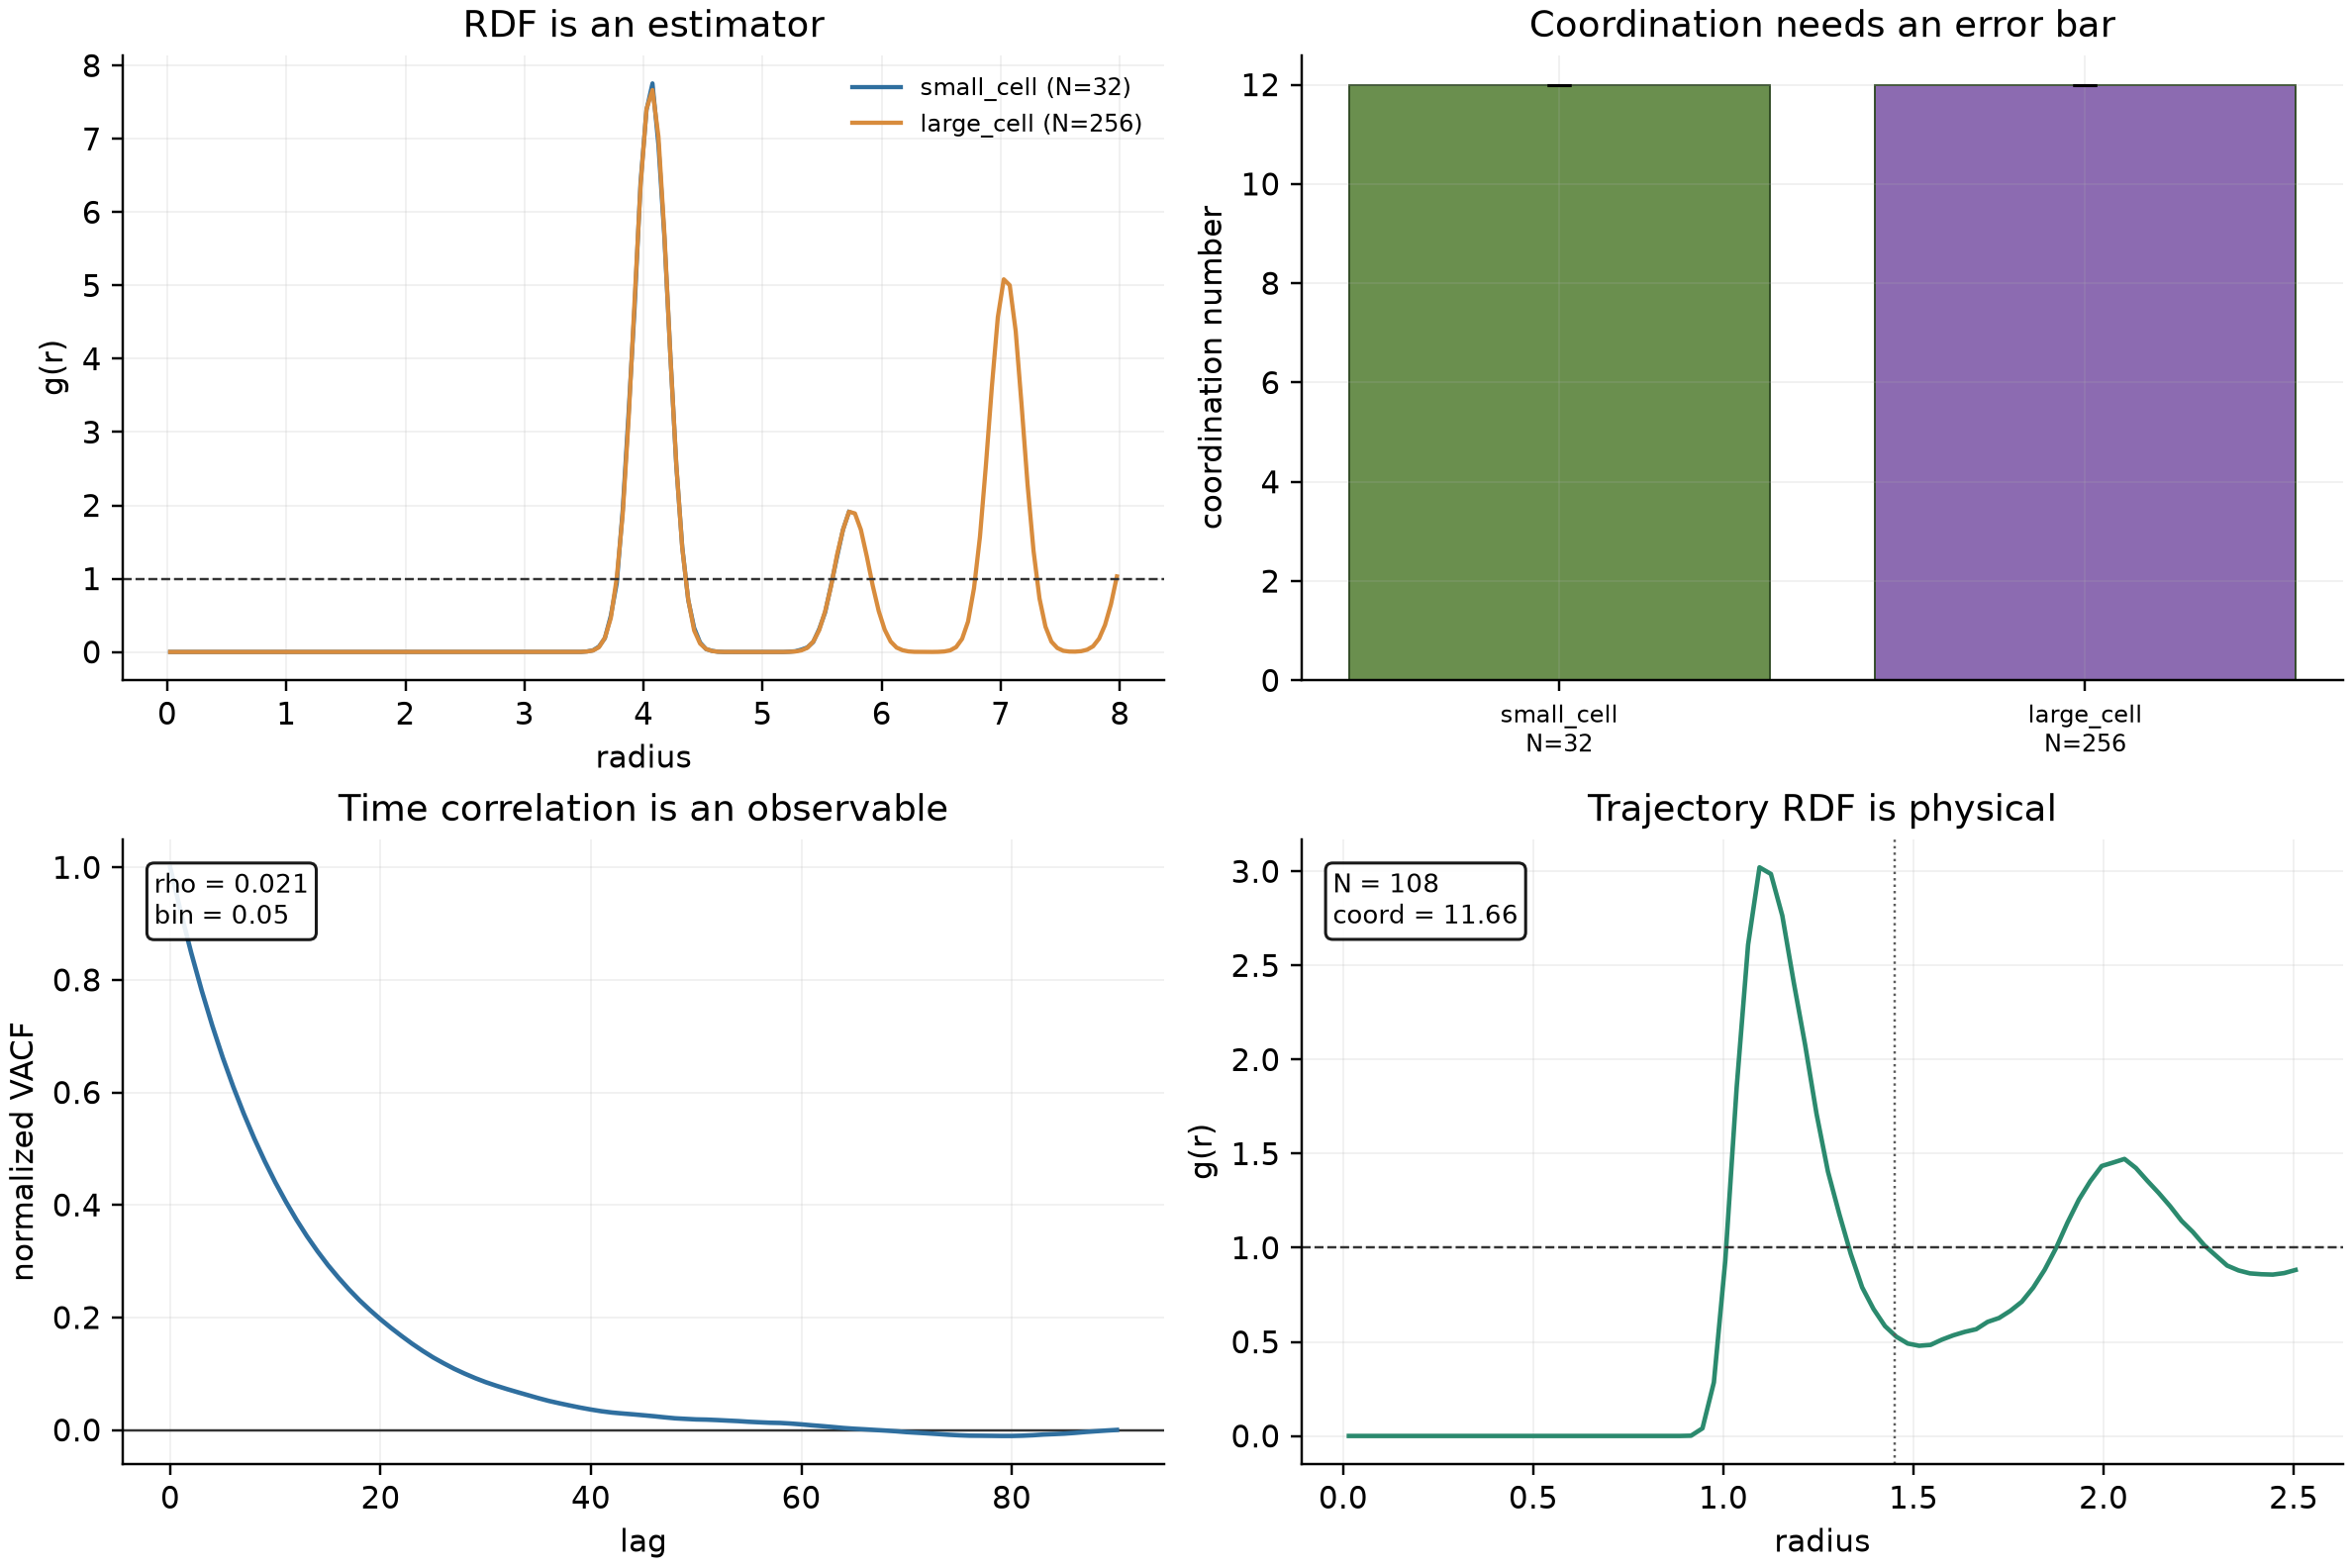

In [5]:
generate_post07_figures(
    result_dir=Path("results/post-07/full"),
    figure_dir=Path("figures/post-07"),
    snapshot_dir=Path("snapshots/post-07"),
    name="observable_diagnostics_full",
)
display(Image(filename="figures/post-07/observable_diagnostics_full.png"))